# ***Phase 2.1***

# Import Libraries

In [ ]:
# ===========================
# Import Libraries
# ===========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np      #For numeric Operations
import pandas as pd     #Load and manipulate the dataset

import matplotlib.pyplot as plt   # Plot graphs
import seaborn as sns             #Better visualizations(see patterns in data)

# Train Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Pipeline
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save Model
import joblib

# Load Dataset

In [ ]:
# ===========================
# Upload Dataset
# ===========================

from google.colab import files

uploaded = files.upload()

Saving sonar data.csv to sonar data.csv


## Data Loading

In this section, we load the Sonar dataset and inspect its structure.

In [ ]:
# ===========================
# Load Dataset
# ===========================

df = pd.read_csv("sonar data.csv", header=None)

In [ ]:
print("First Five Rows")
display(df.head())

print("\nShape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

First Five Rows


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R



Shape
(208, 61)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  2

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


# Check Missing Values

In [ ]:
print(df.isnull().sum())

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64


# Visualize Class Distribution

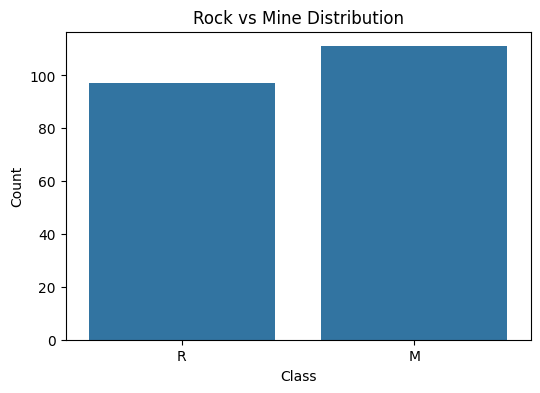

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=df[60])

plt.title("Rock vs Mine Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

# Separate Features & Target

In [ ]:
# Features
X = df.iloc[:, :-1]

# Target
y = df.iloc[:, -1]

# Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Create meaningful feature names
feature_names = [f"Signal_{i+1}" for i in range(X_train.shape[1])]

X_train.columns = feature_names
X_test.columns = feature_names

# Pipelines

In [ ]:
models = {

    "Logistic Regression": Pipeline([

        ("Scaler", StandardScaler()),

        ("Model", LogisticRegression(max_iter=1000))

    ]),

    "Support Vector Machine": Pipeline([

        ("Scaler", StandardScaler()),

        ("Model", SVC())

    ]),

    "Decision Tree": Pipeline([

        ("Model", DecisionTreeClassifier(
            random_state=42
        ))

    ]),

    "Random Forest": Pipeline([

        ("Model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))

    ])

}

## Model Training

We compare multiple classification algorithms to identify
the best-performing model for sonar signal classification.

In [ ]:
results = []

for name, model in models.items():

    # Train the model using the training dataset
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)   # storing the models prediction in y_pred

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)   #comparing with  actual pred(y_test) and models prediction(y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="M"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="M"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="M"
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

# Compare Models

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.880952,0.814815,1.000000,0.897959
1,Support Vector Machine,0.857143,0.807692,0.954545,0.875000
0,Logistic Regression,0.833333,0.777778,0.954545,0.857143
2,Decision Tree,0.785714,0.760000,0.863636,0.808511


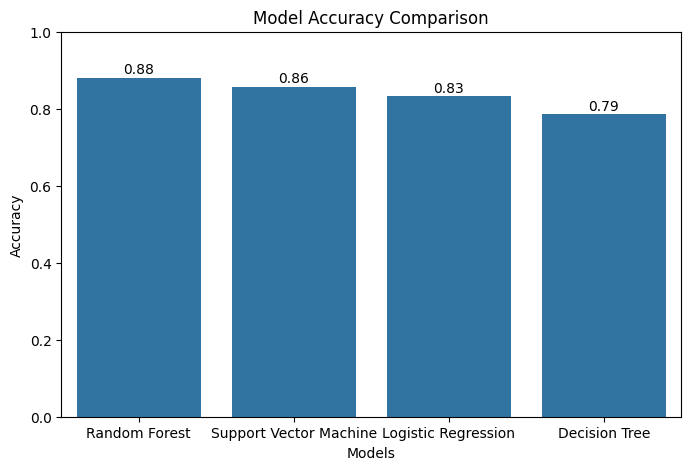

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.ylim(0,1)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.show()

# Save the Best Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print(f"Best Model: {best_model_name}")

print("Model Saved Successfully!")

Best Model: Random Forest
Model Saved Successfully!


# ***Phase 2.2 - SKF Cross Validation for Every Model***



Used StratifiedKFold beacause with a relatively small number of samples, StratifiedKFold preserves the Rock/Mine class balance in every fold and makes the evaluation more robust

StratifiedKFold guarantees that every fold contains the exact same proportion of target classes as the entire dataset

In [ ]:

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

    print("=" * 50)
    print(f"Model: {name}")
    print(f"Fold Accuracies: {scores}")
    print(f"Average Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")

Model: Logistic Regression
Fold Accuracies: [0.76190476 0.78571429 0.80952381 0.7804878  0.7804878 ]
Average Accuracy: 0.7836
Standard Deviation: 0.0153
Model: Support Vector Machine
Fold Accuracies: [0.85714286 0.80952381 0.85714286 0.90243902 0.7804878 ]
Average Accuracy: 0.8413
Standard Deviation: 0.0423
Model: Decision Tree
Fold Accuracies: [0.66666667 0.73809524 0.71428571 0.68292683 0.75609756]
Average Accuracy: 0.7116
Standard Deviation: 0.0333
Model: Random Forest
Fold Accuracies: [0.80952381 0.80952381 0.76190476 0.90243902 0.85365854]
Average Accuracy: 0.8274
Standard Deviation: 0.0474


# Create Cross Validation Table

In [ ]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

display(cv_results_df)

,Model,CV Mean Accuracy,CV Std
1,Support Vector Machine,0.841347,0.042303
3,Random Forest,0.827410,0.047432
0,Logistic Regression,0.783624,0.015275
2,Decision Tree,0.711614,0.033258


# Normal Accuracy vs Five Fold Accuracy

In [ ]:
final_results = pd.merge(
    results_df,
    cv_results_df,
    on="Model"
)

final_results = final_results.sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std
1,Support Vector Machine,0.857143,0.807692,0.954545,0.875000,0.841347,0.042303
0,Random Forest,0.880952,0.814815,1.000000,0.897959,0.827410,0.047432
2,Logistic Regression,0.833333,0.777778,0.954545,0.857143,0.783624,0.015275
3,Decision Tree,0.785714,0.760000,0.863636,0.808511,0.711614,0.033258


# Visualize Cross Validation Results

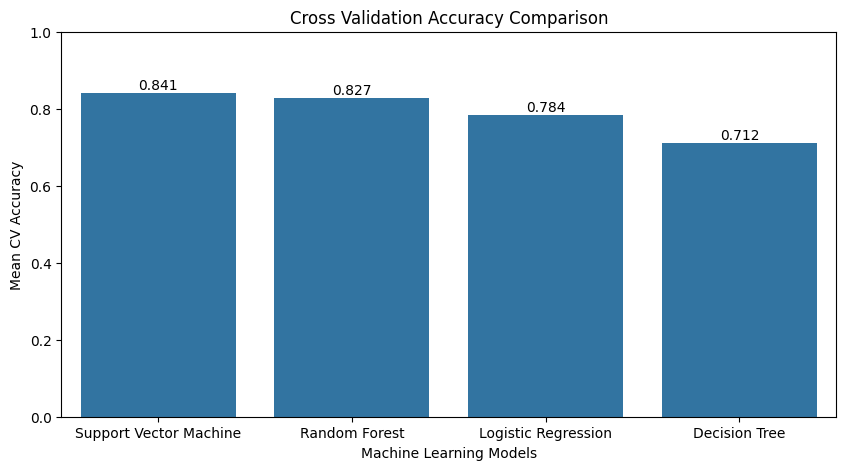

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x="Model",
    y="CV Mean Accuracy"
)

plt.title("Cross Validation Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(final_results["CV Mean Accuracy"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.show()

# Select the Best Model Based on Cross Validation

In [ ]:
# Temporary best model after Phase 2.2
best_model_name = final_results.iloc[0]["Model"]

best_model = models[best_model_name]

print("=" * 50)
print(f"Best Model (Cross Validation): {best_model_name}")
print("=" * 50)

Best Model (Cross Validation): Support Vector Machine


# ***Phase 2.3 - HyperParameter Tuning of Top 2 best performing Model***

# Create Parameter Grid for SVM

In this phase we will do Hyperparameter tuning for Random Forest and SVM as they were the top two best performing

We are using GridSearchCV as it tries every combination automatically

In [ ]:
from sklearn.model_selection import GridSearchCV

#SVM Parameters
svm_params = {

    "Model__C": [0.01, 0.1, 1, 10, 50, 100],

    "Model__kernel": [
        "linear",
        "rbf"
    ],

    "Model__gamma": [
        "scale",
        "auto"
    ]
}

# Tune SVM

In [ ]:
svm_grid = GridSearchCV(

    estimator=models["Support Vector Machine"],

    param_grid=svm_params,

    cv=skf,

    scoring="accuracy",

    n_jobs=-1

)

svm_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('Scaler', StandardScaler()),
                                       ('Model', SVC())]),
             n_jobs=-1,
             param_grid={'Model__C': [0.01, 0.1, 1, 10, 50, 100],
                         'Model__gamma': ['scale', 'auto'],
                         'Model__kernel': ['linear', 'rbf']},
             scoring='accuracy')

#Best Parameters & Accuracy for Tuned SVM after Stratified Cross Validation

In [ ]:
print("=" * 50)
print("Best SVM Parameters")
print("=" * 50)

print(svm_grid.best_params_)

print("\nBest CV Score")

print(svm_grid.best_score_)

Best SVM Parameters
{'Model__C': 10, 'Model__gamma': 'scale', 'Model__kernel': 'rbf'}

Best CV Score
0.8614973262032086


# Create Parameter Grid for Random Forest

In [ ]:
rf_params = {

    "Model__n_estimators":[
        100,
        200,
        300
    ],

    "Model__max_depth":[
        None,
        5,
        10,
        20
    ],

    "Model__min_samples_split":[
        2,
        5,
        10
    ]
}

# Tune Random Forest

In [ ]:
rf_grid = GridSearchCV(

    estimator=models["Random Forest"],

    param_grid=rf_params,

    cv=skf,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('Model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'Model__max_depth': [None, 5, 10, 20],
                         'Model__min_samples_split': [2, 5, 10],
                         'Model__n_estimators': [100, 200, 300]},
             scoring='accuracy')

#Best Parameters & Accuracy  for Tuned Random Forest after Stratified Cross validation





In [ ]:
print("=" * 50)
print("Best Random Forest Parameters")
print("=" * 50)

print(rf_grid.best_params_)

print("\nBest CV Score")

print(rf_grid.best_score_)

Best Random Forest Parameters
{'Model__max_depth': None, 'Model__min_samples_split': 5, 'Model__n_estimators': 100}

Best CV Score
0.8317290552584671


# Compare Tuned Models

In [ ]:
tuned_results = pd.DataFrame({

    "Model":[

        "Support Vector Machine",

        "Random Forest"

    ],

    "Best CV Accuracy":[

        svm_grid.best_score_,

        rf_grid.best_score_

    ]

})

display(tuned_results.sort_values(
    by="Best CV Accuracy",
    ascending=False
))

,Model,Best CV Accuracy
0,Support Vector Machine,0.861497
1,Random Forest,0.831729


# Testing the tuned SVM model on Unseen data(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

best_svm = svm_grid.best_estimator_

y_pred = best_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Tuned SVM Test Accuracy: {accuracy:.4f}")

Tuned SVM Test Accuracy: 0.8810


# Testing the tuned RF model on Unseen data(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Tuned RF Test Accuracy: {accuracy:.4f}")

Tuned RF Test Accuracy: 0.8810


# Phase 2.4 - Advanced Ensemble Models (CatBoost & XGBoost)

In this phase, we compare modern boosting algorithms with the best model obtained from hyperparameter tuning.

# Install Required Libraries

In [ ]:
!pip install -q xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


# Import XGBoost and CatBoost

In [ ]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Prepare Encoded Labels for Boosting Models

Ensemble models requires the target labels to be numeric (0 and 1) so we are converting the y class labels from (R/M) to (0/1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train XGBoost Classifier

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluate XGBoost on Test Set

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred)

print("="*50)
print("XGBoost Test Accuracy")
print("="*50)
print(f"{xgb_accuracy:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test_encoded, xgb_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test_encoded, xgb_pred))

XGBoost Test Accuracy
0.9286

Classification Report

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.85      0.92        20

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42


Confusion Matrix

[[22  0]
 [ 3 17]]


## Cross Validation of XGBoost

Without Shuffling similar samples are grouped together in the original dataset order, some folds become much harder than others which results in drop of accuracy that's why  we used shuffle = True

In [ ]:
from sklearn.model_selection import StratifiedKFold


y_encoded = label_encoder.transform(y)

xgb_cv = cross_val_score(
    xgb_model,
    X,
    y_encoded,
    cv=skf,
    scoring="accuracy"
)

print("Fold accuracies:", xgb_cv)
print("Mean:", xgb_cv.mean())
print("Std:", xgb_cv.std())

Fold accuracies: [0.85714286 0.78571429 0.73809524 0.87804878 0.90243902]
Mean: 0.832288037166086
Std: 0.06111360967092861


# Train CatBoost Classifier

In [ ]:
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train_encoded)

CatBoostClassifier(random_state=42, verbose=0)

# Evaluate CatBoost on Test Set

In [ ]:
cat_pred = cat_model.predict(X_test)

cat_accuracy = accuracy_score(y_test_encoded, cat_pred)

print("="*50)
print("CatBoost Test Accuracy")
print("="*50)
print(f"{cat_accuracy:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test_encoded, cat_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test_encoded, cat_pred))

CatBoost Test Accuracy
0.9048

Classification Report

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        22
           1       1.00      0.80      0.89        20

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42


Confusion Matrix

[[22  0]
 [ 4 16]]


 # Stratified Cross Validation of Tuned Catboost (without tuning)


In [ ]:
from sklearn.model_selection import StratifiedKFold


cat_cv = cross_val_score(
    cat_model,
    X,
    y_encoded,
    cv=skf,
    scoring="accuracy"
)

print("Fold accuracies:", cat_cv)
print("Mean:", cat_cv.mean())
print("Std:", cat_cv.std())

Fold accuracies: [0.88095238 0.9047619  0.76190476 0.87804878 0.92682927]
Mean: 0.870499419279907
Std: 0.05710696397814356


# Compare Advanced Ensemble Models

In [ ]:
advanced_results = pd.DataFrame({

    "Model":[
        "Tuned SVM",
        "Tuned Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Test Accuracy":[
        best_svm.score(X_test, y_test),
        best_rf.score(X_test, y_test),
        xgb_accuracy,
        cat_accuracy
    ],

    "CV Accuracy":[
        svm_grid.best_score_,
        rf_grid.best_score_,
        xgb_cv.mean(),
        cat_cv.mean()
    ]

})

advanced_results = advanced_results.sort_values(
    by="CV Accuracy",
    ascending=False
)

display(advanced_results)

,Model,Test Accuracy,CV Accuracy
3,CatBoost,0.904762,0.870499
0,Tuned SVM,0.880952,0.861497
2,XGBoost,0.928571,0.832288
1,Tuned Random Forest,0.880952,0.831729


# *# Phase 2.4.1 - Hyperparameter Tuning - CatBoost Classifier*

Optimize the CatBoost classifier using GridSearchCV to find the best combination of hyperparameters.

# Define Parameter Grid for CatBoost

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
cat_param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [100, 200, 300]
}

# Grid Search

In [ ]:
cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1   #use all cpu cores
)

cat_grid.fit(X_train, y_train_encoded)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=CatBoostClassifier(random_state=42, verbose=0),
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200, 300],
                         'learning_rate': [0.01, 0.05, 0.1]},
             scoring='accuracy')

# Best Parameters of CatBoost after tuning

In [ ]:
print("="*50)
print("Best CatBoost Parameters")
print("="*50)

print(cat_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{cat_grid.best_score_:.4f}")

Best CatBoost Parameters
{'depth': 6, 'iterations': 300, 'learning_rate': 0.05}

Best Cross Validation Accuracy:
0.8793


# Storing Best Tuned Model of CatBoost

In [ ]:
best_cat = cat_grid.best_estimator_

# Test Evaluation on Unseen data

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

cat_pred = best_cat.predict(X_test)

cat_accuracy = accuracy_score(
    y_test_encoded,
    cat_pred
)

print("="*50)
print("Tuned CatBoost Test Accuracy")
print("="*50)

print(f"{cat_accuracy:.4f}")


Tuned CatBoost Test Accuracy
0.8810


# Stratified Cross Validation of Tuned Catboost

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cat_cv = cross_val_score(
    best_cat,
    X,
    y_encoded,
    cv=skf,
    scoring="accuracy"
)

print("="*50)
print("Tuned CatBoost Cross Validation")
print("="*50)

print("Fold Accuracies:")
print(cat_cv)

print(f"\nMean Accuracy : {cat_cv.mean():.4f}")
print(f"Std Deviation : {cat_cv.std():.4f}")

Tuned CatBoost Cross Validation
Fold Accuracies:
[0.83333333 0.92857143 0.76190476 0.87804878 0.92682927]

Mean Accuracy : 0.8657
Std Deviation : 0.0627


# Define Parameter Grid for XGBoost

In [ ]:
xgb_params = {

    "n_estimators": [100, 200, 300],

    "learning_rate": [0.01, 0.1, 0.3],

    "max_depth": [3, 5, 7]

}

# Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

xgb_grid = GridSearchCV(

    estimator=xgb_model,

    param_grid=xgb_params,

    cv=skf,

    scoring="accuracy",

    n_jobs=-1

)

xgb_grid.fit(X_train, y_train_encoded)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_p...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

# Best Parameters of XGBoost after tuning


In [ ]:
print("Best Parameters:")
print(xgb_grid.best_params_)

print()

print("Best CV Accuracy:")
print(xgb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}

Best CV Accuracy:
0.8732620320855615


# Storing Best Tuned Model of XGBoost

In [ ]:
best_xgb = xgb_grid.best_estimator_

In [ ]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_xgb, "artifacts/tuned_xgboost_model.pkl")
print("Model saved!")

Model saved!


In [ ]:
loaded_model = joblib.load("artifacts/tuned_xgboost_model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


# Test Evaluation on Unseen data

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = best_xgb.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

print(f"Tuned XGBoost Test Accuracy: {xgb_accuracy:.4f}")

Tuned XGBoost Test Accuracy: 0.9286


# Stratified Cross Validation of Tuned XGBoost

In [ ]:
from sklearn.model_selection import cross_val_score

xgb_cv = cross_val_score(

    best_xgb,

    X,

    y_encoded,

    cv=skf,

    scoring="accuracy"

)

print("Fold Accuracies:")
print(xgb_cv)

print()

print("Average CV Accuracy:")
print(xgb_cv.mean())

print()

print("Standard Deviation:")
print(xgb_cv.std())

Fold Accuracies:
[0.9047619  0.92857143 0.73809524 0.87804878 0.92682927]

Average CV Accuracy:
0.8752613240418119

Standard Deviation:
0.07098423688310454


# Final Comparison

In [ ]:
comparison_df = pd.DataFrame({

    "Model": [

        "Tuned SVM",

        "Tuned Random Forest",

        "Tuned XGBoost",

        "Tuned CatBoost"

    ],

    "Test Accuracy": [

        best_svm.score(X_test, y_test),

        best_rf.score(X_test, y_test),

        xgb_accuracy,

        cat_accuracy

    ],

    "CV Accuracy": [

        svm_grid.best_score_,

        rf_grid.best_score_,

        xgb_cv.mean(),

        cat_cv.mean()

    ]

})

comparison_df = comparison_df.sort_values(

    by="CV Accuracy",

    ascending=False

)

display(comparison_df)

,Model,Test Accuracy,CV Accuracy
2,Tuned XGBoost,0.928571,0.875261
3,Tuned CatBoost,0.880952,0.865738
0,Tuned SVM,0.880952,0.861497
1,Tuned Random Forest,0.880952,0.831729


# Phase 2.5 - Comprehensive Evaluation of the Final Model

After comparing multiple machine learning algorithms, the Tuned XGBoost classifier was selected as the final model based on its superior test accuracy and cross-validation performance.

    Test Accuracy: 92.86%

    Mean Cross-Validation Accuracy: 87.53%


This phase evaluates the selected model using several performance metrics to better understand its classification capability and overall reliability.

In [ ]:
# Final Predictions using the Tuned XGBoost Model

final_predictions = best_xgb.predict(X_test)

# Confusion Matrix

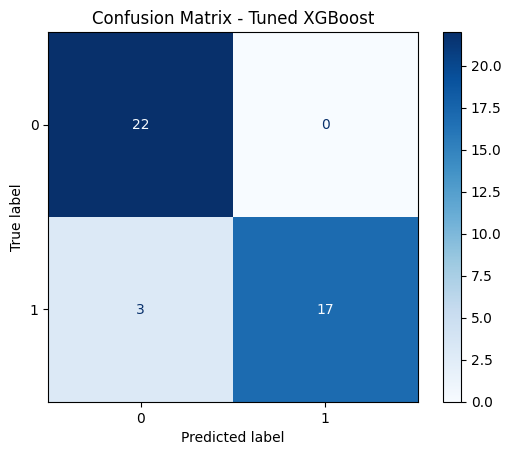

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_test,
    y_test_encoded,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("="*60)
print("Classification Report")
print("="*60)

print(
    classification_report(
        y_test_encoded,
        final_predictions,
        target_names=["Mine", "Rock"]
    )
)

Classification Report
              precision    recall  f1-score   support

        Mine       0.88      1.00      0.94        22
        Rock       1.00      0.85      0.92        20

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



# Precision, Recall, F1, Accuracy

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#Metrics for Rock
accuracy = accuracy_score(
    y_test_encoded,
    final_predictions
)

precision_R = precision_score(
    y_test_encoded,
    final_predictions
)

recall_R = recall_score(
    y_test_encoded,
    final_predictions
)

f1_R = f1_score(
    y_test_encoded,
    final_predictions
)


#Metrics For Mine
precision_M = precision_score(
    y_test_encoded,
    final_predictions,
    pos_label=0
)

recall_M = recall_score(
    y_test_encoded,
    final_predictions,
    pos_label=0
)

f1_M = f1_score(
    y_test_encoded,
    final_predictions,
    pos_label=0
)

print("="*60)
print("Evaluation Metrics")
print("="*60)

#Model Accuracy
print(f"Accuracy  : {accuracy:.4f}")

#Model metrics for Rock
print("\nMetrics for Rock")
print("-"*60)
print(f"Precision : {precision_R:.4f}")
print(f"Recall    : {recall_R:.4f}")
print(f"F1 Score  : {f1_R:.4f}")


#Model metrics for Mine
print("\nMetrics for Mine")
print("-"*60)
print(f"Precision : {precision_M:.4f}")
print(f"Recall    : {recall_M:.4f}")
print(f"F1 Score  : {f1_M:.4f}")

Evaluation Metrics
Accuracy  : 0.9286

Metrics for Rock
------------------------------------------------------------
Precision : 1.0000
Recall    : 0.8500
F1 Score  : 0.9189

Metrics for Mine
------------------------------------------------------------
Precision : 0.8800
Recall    : 1.0000
F1 Score  : 0.9362


## ROC Curve and AUC Score

Unlike accuracy and the confusion matrix, the ROC curve evaluates the classifier using prediction probabilities instead of final class labels.

The Area Under the ROC Curve (AUC) summarizes the model's ability to distinguish between the two classes across all possible classification thresholds.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of the positive class (Rock = 1)
y_prob = best_xgb.predict_proba(X_test)[:, 1]


#The first column is class 0 (Mine).

#The second column is class 1 (Rock).

#Since ROC requires the probability of the positive class, we select (X_test)[:, 1]

# Compute ROC

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test_encoded,
    y_prob
)

# Calculate AUC

In [ ]:
auc_score = roc_auc_score(
    y_test_encoded,
    y_prob
)

print("="*60)
print("AUC Score")
print("="*60)

print(f"AUC = {auc_score:.4f}")

AUC Score
AUC = 0.9795


# Plot ROC Curve

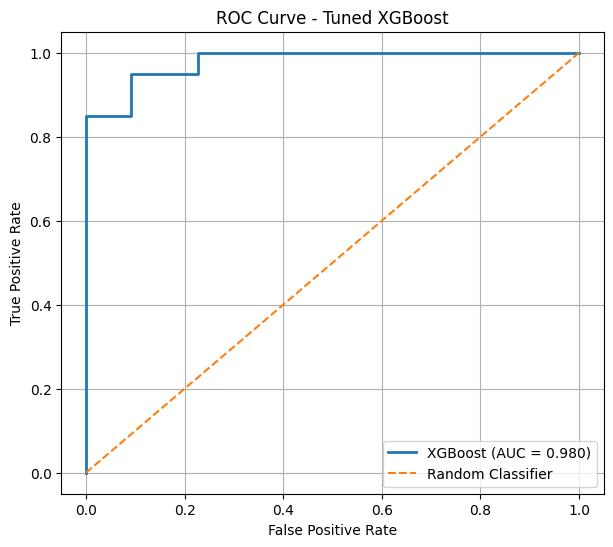

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc_score:.3f})",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")

plt.legend()
plt.grid(True)

plt.show()

## Precision–Recall Curve

The Precision–Recall (PR) Curve illustrates the trade-off between precision and recall across different classification thresholds.

Unlike the ROC curve, which compares the True Positive Rate and False Positive Rate, the PR curve focuses only on the performance of the positive class. It is particularly useful for evaluating models on imbalanced datasets where the positive class is rare.

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)


y_prob = best_xgb.predict_proba(X_test)[:,1]


precision, recall, thresholds = precision_recall_curve(
    y_test_encoded,
    y_prob
)

# Compute Average Precision (AP)

In [ ]:
ap_score = average_precision_score(
    y_test_encoded,
    y_prob
)

print("="*60)
print("Average Precision Score")
print("="*60)

print(f"AP Score = {ap_score:.4f}")

Average Precision Score
AP Score = 0.9802


# Plot the PR Curve

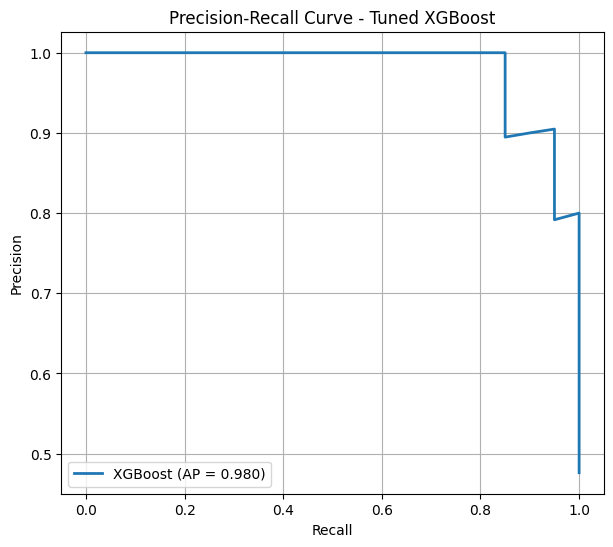

In [ ]:
plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"XGBoost (AP = {ap_score:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Tuned XGBoost")

plt.grid(True)

plt.legend()

plt.show()

### Interpretation

The Precision–Recall (PR) curve demonstrates that the Tuned XGBoost model maintains very high precision across a wide range of recall values.

The model achieved an Average Precision (AP) score of **0.980**, indicating excellent capability in identifying the positive class while minimizing false positive predictions. The slight decline in precision at very high recall values is expected, as lowering the classification threshold causes more samples to be classified as the positive class.

# Phase 2.6 – Model Explainability using SHAP (SHapley Additive exPlanations)

In the previous phases, the Tuned XGBoost model was selected as the final model based on its superior performance across multiple evaluation metrics, including Accuracy, ROC-AUC, and Average Precision. Although the model achieved excellent predictive performance, it still behaves as a black-box model, making it difficult to understand how individual features influence its predictions.

To improve model interpretability, this phase applies SHAP (SHapley Additive exPlanations), a game theory-based explainability technique. SHAP quantifies the contribution of each feature to the model's predictions, allowing both global and local interpretation of the Tuned XGBoost model.

## 2.6.1 Import Required Libraries

In [ ]:
import shap

## 2.6.2 Create the SHAP Tree Explainer

In [ ]:
# Create TreeSHAP Explainer for the Tuned XGBoost Model

explainer = shap.TreeExplainer(best_xgb)

## 2.6.3 Compute SHAP Values

In [ ]:
# Calculate SHAP Values for the Test Set

shap_values = explainer(X_test)

## 2.6.4 Verify the SHAP Explanation Object

In [ ]:
print("Object Type:")
print(type(shap_values))

print("\nSHAP Values Shape:")
print(shap_values.values.shape)

print("\nBase Values Shape:")
print(shap_values.base_values.shape)

print("\nOriginal Data Shape:")
print(shap_values.data.shape)

Object Type:
<class 'shap._explanation.Explanation'>

SHAP Values Shape:
(42, 60)

Base Values Shape:
(42,)

Original Data Shape:
(42, 60)


## 2.6.5 Global Feature Importance using SHAP Summary (Beeswarm) Plot

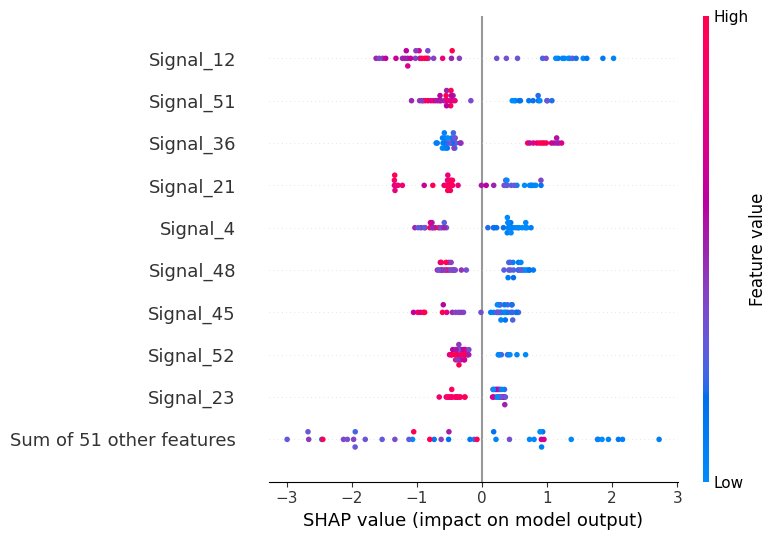

In [ ]:
# SHAP Summary (Beeswarm) Plot


plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

The SHAP Summary (Beeswarm) Plot provides a global explanation of the Tuned XGBoost model by displaying the distribution of SHAP values for each feature across all test samples. Features are ranked according to their mean absolute SHAP values, indicating their overall importance in the model. Each point represents one test sample, where the horizontal position indicates the feature's contribution to the prediction, and the color represents the original feature value (blue for low values and red for high values). The plot shows that Features 12, 51, and 36 have the greatest influence on the model's predictions, while the remaining features contribute comparatively less. The distribution of red and blue points also reveals whether higher or lower feature values tend to push predictions toward either the Rock or Mine class.

## 2.6.6 Global Feature Importance using SHAP Bar Plot

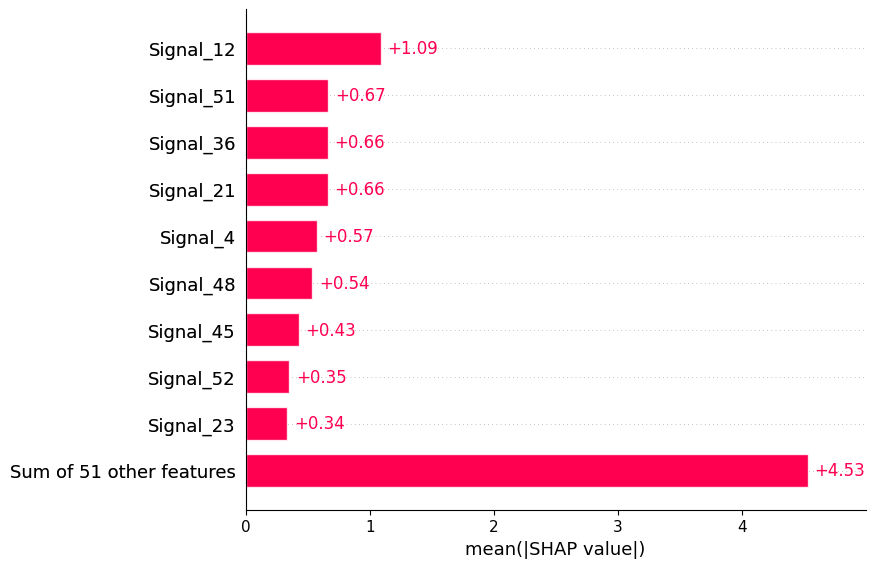

In [ ]:
# SHAP Feature Importance Bar Plot

shap.plots.bar(shap_values)

# 2.6.7 SHAP Dependence Plot

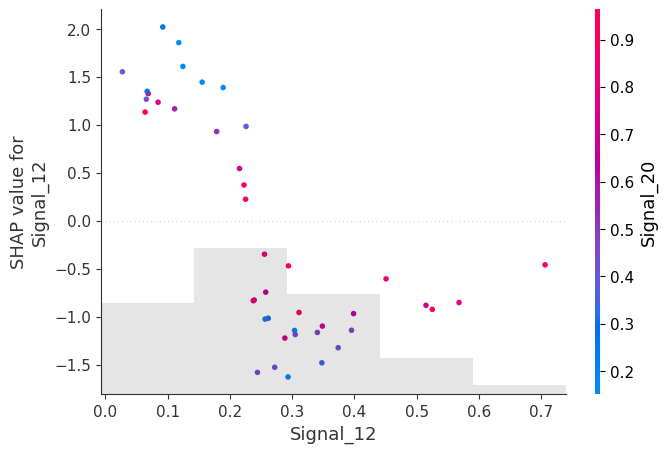

In [ ]:
# SHAP Dependence Plot for the Most Important Feature

shap.plots.scatter(
    shap_values[:, "Signal_12"],
    color=shap_values
)

The model has learned that lower values of Signal_12 generally increase the likelihood of the Rock class, while higher values generally increase the likelihood of the Mine class. The dependence plot suggests a transition region around 0.22–0.25 where the contribution of Signal_12 changes from generally positive to generally negative, indicating a nonlinear relationship consistent with tree-based decision boundaries

## 2.6.8 Local Explanation using SHAP Waterfall Plot

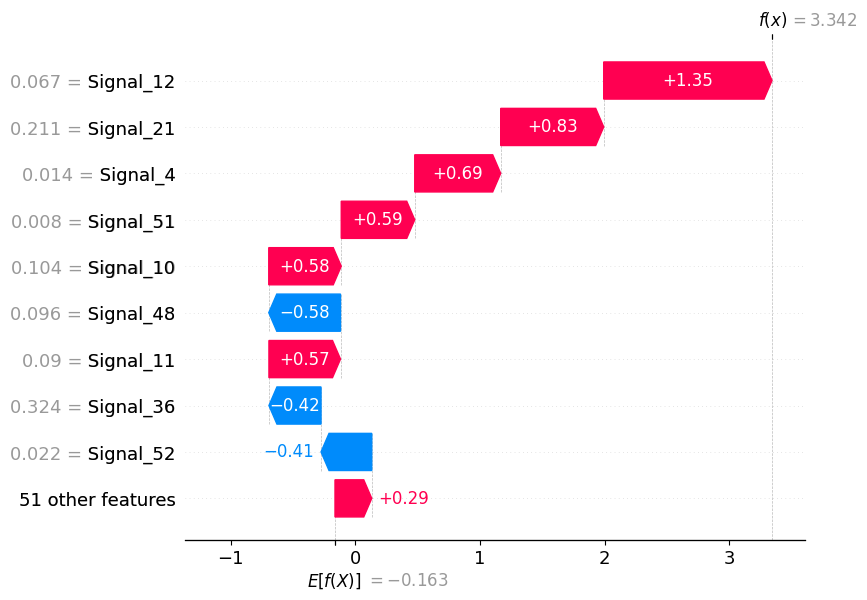

In [ ]:
# Waterfall Plot for the First Test Sample

shap.plots.waterfall(shap_values[0])

The SHAP Waterfall Plot explains the prediction for an individual test sample (0) by showing how each feature contributed to the model's final decision. The prediction starts from the model's baseline output (E[f(X)] = -0.163), and each feature either increases or decreases the prediction. For this sample, Signal_12 had the largest positive contribution (+1.35), followed by Signal_21 (+0.83) and Signal_4 (+0.69), pushing the prediction toward the Rock class. Conversely, Signal_48, Signal_36, and Signal_52 reduced the prediction by providing evidence toward the Mine class. The combined effect of all feature contributions produced a final model output of f(x) = 3.342, resulting in a confident prediction for the Rock class.

## 2.6.9 Local Explanation using SHAP Force Plot

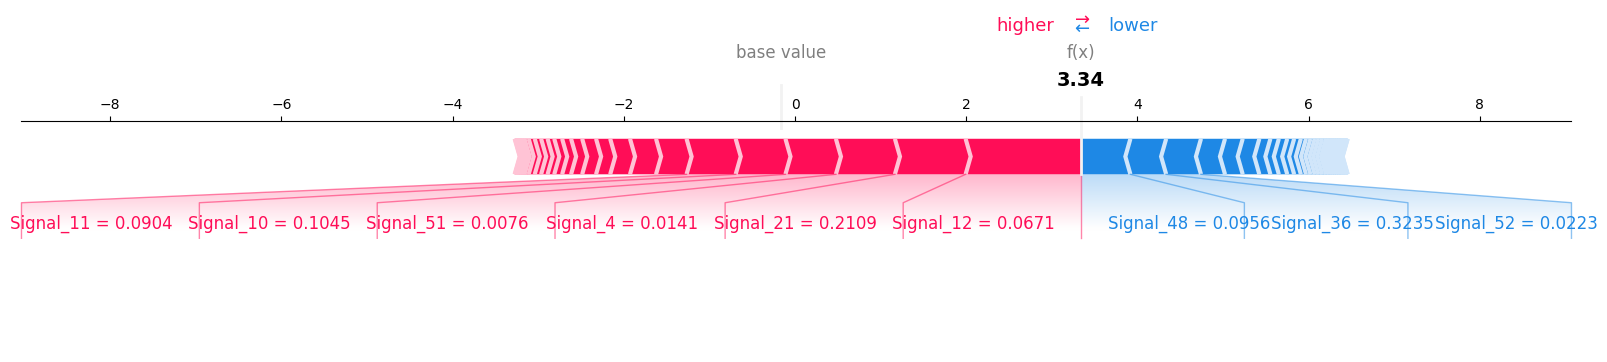

In [ ]:
# SHAP Force Plot for the First Test Sample
shap.initjs()
shap.plots.force(
    shap_values[0],
    matplotlib=True
)

##2.6.10 Key Explainability Findings

Key Explainability Findings

SHAP (SHapley Additive exPlanations) was used to interpret the predictions of the final tuned XGBoost model. Unlike traditional feature importance methods, SHAP provides both global and local explanations, allowing us to understand not only which features are important but also how they influence individual predictions.

The key findings from the explainability analysis are:

The SHAP Beeswarm Plot revealed that only a small subset of the 60 sonar signal features contributed significantly to the model's predictions. Features such as Signal_12, Signal_51, Signal_36, Signal_21, and Signal_4 consistently had the highest impact on the model output.
The SHAP Feature Importance Bar Plot confirmed the global ranking of feature importance based on the mean absolute SHAP values, validating the observations from the Beeswarm Plot.
The SHAP Waterfall Plot explained the prediction of an individual test sample by showing how each feature contributed to the final decision. Starting from the model's baseline output (E[f(X)] = -0.163), positive SHAP values pushed the prediction toward the Rock class, while negative SHAP values pushed it toward the Mine class. For the analyzed sample, the positive contributions were substantially larger than the negative contributions, resulting in a final model output of 3.342, corresponding to a confident prediction of Rock.
The SHAP Force Plot provided an alternative visualization of the same local explanation by illustrating how different features collectively pushed and pulled the prediction away from the baseline. It clearly demonstrated the balance between supporting and opposing feature contributions.
The SHAP Dependence Plot showed how the contribution of Signal_12 changed with its feature value. Lower values of Signal_12 generally produced positive SHAP values (favoring the Rock class), whereas higher values tended to produce negative SHAP values (favoring the Mine class). The plot also suggested a nonlinear relationship between the feature value and its contribution, highlighting the complex decision boundaries learned by the XGBoost model.

Overall, the SHAP analysis confirmed that the tuned XGBoost model makes predictions based on meaningful patterns learned from the sonar signals rather than treating all features equally. The combination of global and local explainability improves the transparency, interpretability, and trustworthiness of the final machine learning model.

# Phase 3 – Model Serialization & Inference Pipeline

## 3.1 Create Artifacts Directory

In [ ]:

import os

# Create artifacts directory if it doesn't already exist
os.makedirs("artifacts", exist_ok=True)

print("Artifacts directory is ready.")

Artifacts directory is ready.


## 3.2 Artifact Save the Final Tuned XGBoost Model



In [ ]:
import joblib

joblib.dump(
    best_xgb,
    "artifacts/tuned_xgboost_model.pkl"
)

print("✅ Tuned XGBoost model saved successfully.")

✅ Tuned XGBoost model saved successfully.


## 3.3 Load the Saved Model

In [ ]:

import joblib

# Load the saved model
loaded_xgb = joblib.load("artifacts/tuned_xgboost_model.pkl")

print("✅ Tuned XGBoost model loaded successfully.")

✅ Tuned XGBoost model loaded successfully.


In [ ]:
type(loaded_xgb)

xgboost.sklearn.XGBClassifier

In [ ]:


import numpy as np

original_predictions = best_xgb.predict(X_test)
loaded_predictions = loaded_xgb.predict(X_test)

if np.array_equal(original_predictions, loaded_predictions):
    print("✅ Verification Passed: Loaded model produces identical predictions.")
else:
    print("❌ Verification Failed: Predictions do not match.")

✅ Verification Passed: Loaded model produces identical predictions.


#Phase 3.4 - Save Reamaining Artifact
#Artifact  Feature Names

In [ ]:
# ============================================================
# Save Feature Names
# ============================================================

joblib.dump(
    list(X_train.columns),
    "artifacts/feature_names.pkl"
)

print("✅ Feature names saved successfully.")

✅ Feature names saved successfully.


# Artifact Feature Order

In [ ]:
# ============================================================
# Save Feature Order
# ============================================================

joblib.dump(
    list(X_train.columns),
    "artifacts/feature_order.pkl"
)

print("✅ Feature order saved successfully.")

✅ Feature order saved successfully.


# Save Label Encoder

In [ ]:
joblib.dump(
    label_encoder,
    "artifacts/label_encoder.pkl"
)

print("✅ Label encoder saved successfully.")

✅ Label encoder saved successfully.


In [ ]:
import os

print(os.listdir("artifacts"))

['tuned_xgboost_model.pkl', 'label_encoder.pkl', 'feature_names.pkl', 'feature_order.pkl']


#Phase 3.5 – Building a Production-Ready Inference Pipeline

##Step 1

In [ ]:
import numpy as np

def validate_input(sample, expected_features=60):
    """
    Validate user input before prediction.

    Parameters
    ----------
    sample : list, tuple, np.ndarray
        Input feature vector.

    expected_features : int
        Number of features expected by the model.

    Returns
    -------
    np.ndarray
        Validated NumPy array.
    """

    # Convert to NumPy array
    sample = np.asarray(sample, dtype=float)

    # Check feature count
    if sample.size != expected_features:
        raise ValueError(
            f"Expected {expected_features} features, "
            f"but received {sample.size}."
        )

    # Check missing values
    if np.isnan(sample).any():
        raise ValueError(
            "Input contains missing (NaN) values."
        )

    return sample

##Step-2

In [ ]:
def prepare_input(sample):
    """
    Prepare validated input for model inference.

    Parameters
    ----------
    sample : np.ndarray
        Validated feature vector.

    Returns
    -------
    np.ndarray
        Reshaped input ready for prediction.
    """

    return sample.reshape(1, -1)

Step-3

In [ ]:
def predict_with_model(sample, model):
    """
    Generate prediction and class probabilities using the trained model.

    Parameters
    ----------
    sample : np.ndarray
        Prepared input with shape (1, 60).

    model : object
        Loaded trained model.

    Returns
    -------
    tuple
        prediction (int)
        probabilities (np.ndarray)
    """

    prediction = model.predict(sample)[0]
    probabilities = model.predict_proba(sample)[0]

    return prediction, probabilities

##Step 4

In [ ]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(loaded_xgb)


def calculate_shap_values(sample, explainer):
    """
    Calculate SHAP values for a single prepared sample.

    Parameters
    ----------
    sample : np.ndarray
        Prepared input with shape (1, 60).

    explainer : shap.TreeExplainer
        SHAP explainer object.

    Returns
    -------
    np.ndarray
        SHAP values for the sample.
    """

    shap_values = explainer.shap_values(sample)

    return shap_values

##Step 5

In [ ]:
import numpy as np

def generate_explanation(
    prediction,
    probabilities,
    shap_values,
    sample,
    feature_names=None,
    top_n=5
):
    """
    Generate a detailed explanation for a prediction.
    """

    shap_values = shap_values.flatten()
    sample = sample.flatten()

    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(len(sample))]

    confidence = float(probabilities[prediction] * 100)

    if confidence >= 95:
        confidence_level = "Very High"
    elif confidence >= 85:
        confidence_level = "High"
    elif confidence >= 70:
        confidence_level = "Moderate"
    elif confidence >= 55:
        confidence_level = "Low"
    else:
        confidence_level = "Very Low"

    predicted_label = "Mine" if prediction == 1 else "Rock"

    # Top SHAP features
    top_idx = np.argsort(np.abs(shap_values))[::-1][:top_n]

    top_features = []

    for idx in top_idx:

        impact = float(shap_values[idx])

        # Impact strength
        abs_impact = abs(impact)

        if abs_impact >= 0.5:
            strength = "Very Strong"
        elif abs_impact >= 0.2:
            strength = "Strong"
        elif abs_impact >= 0.05:
            strength = "Moderate"
        else:
            strength = "Weak"

        direction = (
            "Supports Mine"
            if impact > 0
            else "Supports Rock"
        )

        top_features.append({

            "feature": feature_names[idx],

            "value": round(float(sample[idx]), 4),

            "shap_impact": round(impact, 4),

            "impact_strength": strength,

            "direction": direction

        })

    explanation = (
        f"The model classified this sonar signal as {predicted_label} "
        f"with {confidence:.2f}% confidence ({confidence_level}). "
        f"The prediction was primarily influenced by the top contributing "
        f"features shown below."
    )

    if confidence >= 90:

        recommendation = (
            "The prediction is considered highly reliable."
        )

    elif confidence >= 70:

        recommendation = (
            "The prediction is reasonably reliable but should be interpreted with caution."
        )

    else:

        recommendation = (
            "The prediction has relatively low confidence and should be interpreted carefully."
        )

    return {

        "confidence": confidence,

        "confidence_level": confidence_level,

        "prediction_summary":
            f"{predicted_label} ({confidence:.2f}% confidence)",

        "top_features": top_features,

        "recommendation": recommendation,

        "explanation": explanation

    }

##Step 6

In [ ]:
def format_prediction(prediction,
                      probabilities,
                      explanation_data,
                      shap_values=None,
                      include_shap=False):
    """
    Format prediction results into a structured dictionary.
    """

    result = {

        "prediction": "Mine" if prediction == 1 else "Rock",

        "confidence": round(float(probabilities[prediction] * 100), 2),

        "confidence_level": explanation_data["confidence_level"],

        "rock_probability": round(float(probabilities[0] * 100), 2),

        "mine_probability": round(float(probabilities[1] * 100), 2),

        "prediction_summary": explanation_data["prediction_summary"],

        "top_features": explanation_data["top_features"],

        "recommendation": explanation_data["recommendation"],

        "explanation": explanation_data["explanation"]

    }

    # Only include SHAP values if requested
    if include_shap:
        result["shap_values"] = shap_values

    return result

##Step 7

In [ ]:
def predict_sonar(sample, model, explainer):
    """
    End-to-end prediction pipeline for Rock vs Mine classification.

    Parameters
    ----------
    sample : list, tuple, np.ndarray
        Input feature vector containing 60 features.

    model : object
        Trained machine learning model.

    explainer : shap.TreeExplainer
        SHAP explainer for the trained model.

    Returns
    -------
    dict
        Prediction result or error information.
    """

    try:
        # Step 1: Validate input
        sample = validate_input(sample)

        # Step 2: Prepare input
        sample = prepare_input(sample)

        # Step 3: Generate prediction
        prediction, probabilities = predict_with_model(
            sample,
            model
        )

        # Step 4: Calculate SHAP values
        shap_values = calculate_shap_values(
            sample,
            explainer
        )

        # Step 5: Generate explanation
        explanation = generate_explanation(
            prediction,
            probabilities,
            shap_values,
            sample
        )

        # Step 6: Format final output
        result = format_prediction(
            prediction,
            probabilities,
            explanation,
            shap_values,
            include_shap=False
        )

        # Prediction successful
        result["success"] = True

        return result

    except ValueError as e:
        return {
            "success": False,
            "error": str(e)
        }

    except Exception as e:
        return {
            "success": False,
            "error": f"Unexpected error: {str(e)}"
        }

In [ ]:
result = predict_sonar(
    X_test.iloc[0],
    loaded_xgb,
    explainer
)

from pprint import pprint
pprint(result)

{'confidence': 96.59,
 'confidence_level': 'Very High',
 'explanation': 'The model classified this sonar signal as Mine with 96.59% '
                'confidence (Very High). The prediction was primarily '
                'influenced by the top contributing features shown below.',
 'mine_probability': 96.59,
 'prediction': 'Mine',
 'prediction_summary': 'Mine (96.59% confidence)',
 'recommendation': 'The prediction is considered highly reliable.',
 'rock_probability': 3.41,
 'success': True,
 'top_features': [{'direction': 'Supports Mine',
                   'feature': 'Feature 12',
                   'impact_strength': 'Very Strong',
                   'shap_impact': 1.3498,
                   'value': 0.0671},
                  {'direction': 'Supports Mine',
                   'feature': 'Feature 21',
                   'impact_strength': 'Very Strong',
                   'shap_impact': 0.8262,
                   'value': 0.2109},
                  {'direction': 'Supports Mine',
    

In [ ]:
import xgboost
print(xgboost.__version__)

3.3.0


In [ ]:
import joblib

# Load the saved model
model = joblib.load("artifacts/tuned_xgboost_model.pkl")

print(type(model))
print(model)

<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'catboost_info', 'artifacts', 'best_model.pkl', 'sonar data.csv', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

./best_model.pkl
./artifacts/tuned_xgboost_model.pkl
./artifacts/label_encoder.pkl
./artifacts/feature_names.pkl
./artifacts/feature_order.pkl


In [ ]:
import shutil

# Create a ZIP file of the entire artifacts folder
shutil.make_archive("artifacts", "zip", "artifacts")

'/content/artifacts.zip'

In [ ]:
from google.colab import files

files.download("artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_xgb.save_model("artifacts/tuned_xgboost_model.json")

In [ ]:
from xgboost import XGBClassifier

test_model = XGBClassifier()
test_model.load_model("artifacts/tuned_xgboost_model.json")

print(type(test_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
from google.colab import files
files.download("artifacts/tuned_xgboost_model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>